In [1]:
import jax
from jax import config
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    config.update("jax_platform_name", "gpu")
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/jaxley_rgc
    !pip install -r requirements.txt
    # Uninstall CPU jax/jaxlib if present
    # !pip uninstall -y jax jaxlib

    # # Install GPU-enabled JAX (choose the right cuda extra for your Colab)
    # # Try cuda12 first (common in Colab recently):
    # !pip install -U "jax[cuda12]"
else: 
    config.update("jax_platform_name", "cpu")

In [2]:
from jax.nn import softplus
import jax.numpy as jnp
from utils.training_utils import K_func, ln_forward, make_rgc_forward_with_states
from utils.utils import upsample_hold_edges
from utils.v_to_rate import voltage_batch_to_mu, make_edges
from utils.rgc import build_cell, simulate_one_trial, rgc_forward_sim
from utils.spk_detection import voltage_batch_to_spikes, idx_to_times

import matplotlib.pyplot as plt
import jaxley as jx
plt.rcParams["figure.dpi"] = 100
plt.rcParams['axes.labelsize'] = 18

import seaborn as sns
import pandas as pd
pd.set_option('display.max_columns', None)


# Optimizie LN part only

In [3]:
## Training data
data        = jnp.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_nr.npz", allow_pickle=True)
stim        = data["stim"]
spk_t      = data['spk_times']
spk_train   = data['spk_train']
V_train  = data['raw_traces'] # shape (N_train, T_v) 

## Test Data
data_test   = jnp.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz", allow_pickle=True)
stim_rs        = data_test["stim"]
stimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)
psth           = jnp.mean(spk_t_test, axis=0)

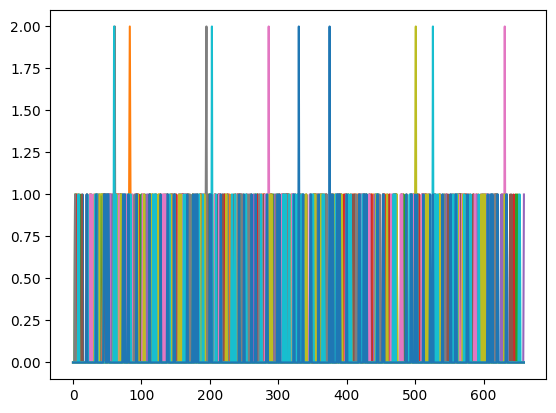

In [4]:
plt.plot(spk_train.T)

In [4]:
import optax
from functools import partial
from jax.nn import sigmoid, softplus
def softplus_inv(y, eps=1e-8):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))

def ln_params(key,
              alpha_j0,
              alpha_h0,
              logit_tau10,
              logit_tau20,
              beta0,
              gain0,
              r0,
              shift0,
              noise):
    eps = noise * jax.random.normal(key, (7,), dtype=jnp.float32)
    return {
      "logit_tau1": jnp.array(logit_tau10, jnp.float32) + eps[0],
      "logit_tau2": jnp.array(logit_tau20, jnp.float32) + eps[1],
      "alpha_j":    jnp.array(alpha_j0,   jnp.float32)  * (1.0 + 0.1*eps[2]),
      "alpha_h":    jnp.array(alpha_h0,   jnp.float32)  * (1.0 + 0.1*eps[3]),
      "log_beta": softplus_inv(beta0) + eps[4],
      "log_gain": softplus_inv(gain0) + eps[5],  # Start with gain ~ 1.0
    "log_r0":     jnp.log(jnp.array(r0,   dtype=jnp.float32)),
      "shift":      jnp.array(shift0, jnp.float32) + 0.05*eps[6],
    }


def poisson_nll_from_rate(rate_hz, y_counts, dt, eps=1e-8):
    y = y_counts.astype(rate_hz.dtype)
    mu = jnp.clip(rate_hz * dt, eps, 1e6)
    return jnp.mean(mu - y * jnp.log(mu))  # + const dropped

def l2_reg(params, keys, w=1e-4):
    return w * sum(jnp.sum(params[k]**2) for k in keys)

@partial(jax.jit, static_argnames=("K","n"))
def loss_fn(params, stim_b, y_b, *, K, dt, n, max_tau):
    rate_hz, _, _ = ln_forward(params, stim_b, K=K, dt=dt, n=n, max_tau=max_tau)
    loss = poisson_nll_from_rate(rate_hz, y_b, dt=dt)
    loss = loss + l2_reg(params, ["alpha_j","alpha_h","logit_tau1","logit_tau2"], w=1e-4)
    loss = loss + l2_reg(params, ["log_gain","shift","log_beta","log_r0"], w=1e-6)
    return loss

@partial(jax.jit, static_argnames=("K","n"))
def train_step(params, opt_state, stim_b, y_b, *, K, dt, n, max_tau):
    loss, grads = jax.value_and_grad(loss_fn)(params, stim_b, y_b, K=K, dt=dt, n=n, max_tau=max_tau)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


In [12]:
# Ensure stim is float; spikes can be int
stim = stim.astype(jnp.float32)
spk_train = spk_train.astype(jnp.int32)

key = jax.random.PRNGKey(0)
params = ln_params(key,
                    alpha_j0=0.16,
                    alpha_h0=0.38,
                    logit_tau10=0.55,
                    logit_tau20=-0.57,
                    beta0=0.25,
                    gain0 = 0.4,
                    r0 = 0.1,
                    shift0=0.304,
                    noise=0.05)
optimizer = optax.adam(3e-3)
opt_state = optimizer.init(params)


frame_rate = 60.0
dt = 1.0 / frame_rate          # Python float is fine
filt_dur = 0.6
K = int(round(filt_dur / dt))  # static integer length for the kernel

max_tau = ((K - 1) / 3.0) * dt  # Python float
n = 6


In [13]:
N, T = stim.shape
batch_size = 16
steps = 3000
rng = key

for step in range(steps):
    rng, k = jax.random.split(rng)
    idx = jax.random.randint(k, (batch_size,), 0, N)

    stim_b = stim[idx]
    y_b    = spk_train[idx]

    params, opt_state, loss = train_step(
    params, opt_state, stim_b, y_b,
    K=K, dt=dt, n=n, max_tau=max_tau
    )

    if step % 100 == 0:
        print(f"step {step:4d} | loss {float(loss):.6f}")


step    0 | loss 0.537863
step  100 | loss 0.498385
step  200 | loss 0.439424
step  300 | loss 0.401018
step  400 | loss 0.381626
step  500 | loss 0.330510
step  600 | loss 0.315442
step  700 | loss 0.300247
step  800 | loss 0.290556
step  900 | loss 0.287408
step 1000 | loss 0.283552
step 1100 | loss 0.286293
step 1200 | loss 0.281078
step 1300 | loss 0.281216
step 1400 | loss 0.280331
step 1500 | loss 0.281178
step 1600 | loss 0.279174
step 1700 | loss 0.273768
step 1800 | loss 0.276388
step 1900 | loss 0.276479
step 2000 | loss 0.274355
step 2100 | loss 0.268677
step 2200 | loss 0.277041
step 2300 | loss 0.275705
step 2400 | loss 0.282458
step 2500 | loss 0.275278
step 2600 | loss 0.271334
step 2700 | loss 0.278994
step 2800 | loss 0.267227
step 2900 | loss 0.276166


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ----- build learned filter + components -----
def get_filter_and_components(params, K, dt, n, max_tau):
    tau_j = sigmoid(params["logit_tau1"]) * max_tau
    tau_h = sigmoid(params["logit_tau2"]) * max_tau

    t = jnp.arange(K, dtype=jnp.float32) * dt
    x1 = t / (tau_j + 1e-12)
    x2 = t / (tau_h + 1e-12)

    Kj = params["alpha_j"] * (x1**n) * jnp.exp(-n*(x1 - 1.0))
    Kh = params["alpha_h"] * (x2**n) * jnp.exp(-n*(x2 - 1.0))
    k  = Kj - Kh

    # apply same norm as training
    k = k / (jnp.sqrt(jnp.sum(k**2) * dt) + 1e-12)
    return t, k, Kj, Kh, tau_j, tau_h

t, k_learned, Kj, Kh, tau_j, tau_h = get_filter_and_components(params, K, dt, n, max_tau)

t = np.array(t)
k_learned = np.array(k_learned)
Kj = np.array(Kj)
Kh = np.array(Kh)

print("tau_j (s):", float(tau_j), "tau_h (s):", float(tau_h))
print("alpha_j:", float(params["alpha_j"]), "alpha_h:", float(params["alpha_h"]))
print("gain:", float(softplus(params["log_gain"])), "r0:", float(softplus(params["log_r0"])))
print("beta:", float(softplus(params["log_beta"])), "shift:", float(params["shift"]))


tau_j (s): 0.12427008897066116 tau_h (s): 0.0709373950958252
alpha_j: 0.15693125128746033 alpha_h: 0.35942867398262024
gain: 2.1243090629577637 r0: 0.12908098101615906
beta: 2.286217451095581 shift: -0.46673622727394104


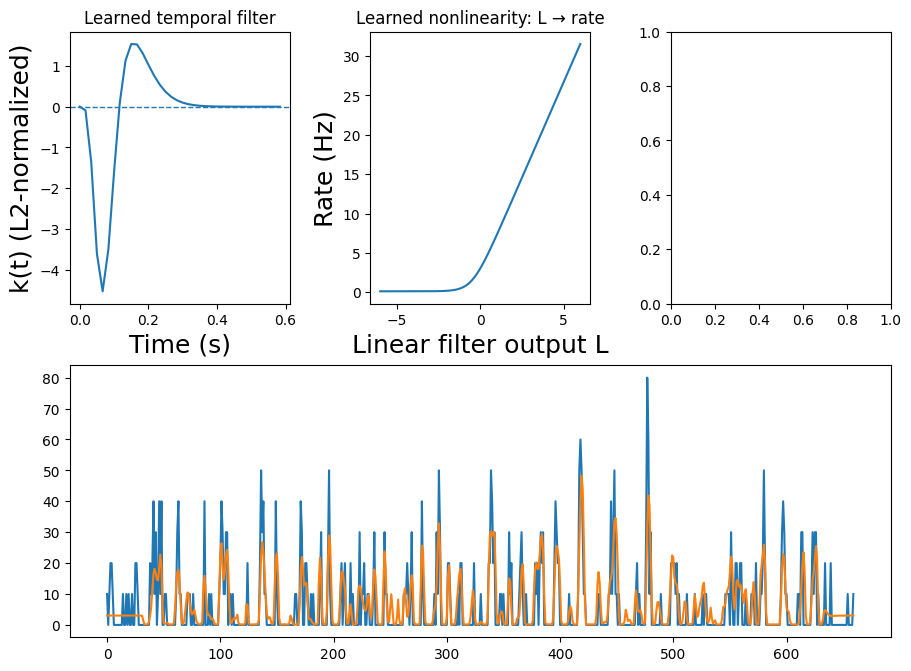

In [8]:
fig = plt.figure(figsize=(6*1.5, 6*1.1), layout="constrained")
gs = fig.add_gridspec(2, 3)

axK  = fig.add_subplot(gs[0, 0])
axNL = fig.add_subplot(gs[0, 1])
axI  = fig.add_subplot(gs[0, 2])
axV  = fig.add_subplot(gs[1, :])  # spans all 3 columns

axK.plot(t, k_learned)
axK.axhline(0, ls="--", linewidth=1)
axK.set_xlabel("Time (s)")
axK.set_ylabel("k(t) (L2-normalized)")
axK.set_title("Learned temporal filter")


# rate_tmp, L_tmp, _ = ln_forward(params, stim[:64], K=K, dt=dt, n=n, max_tau=max_tau)
# L_vals = np.array(L_tmp).ravel()
# lo, hi = np.percentile(L_vals, [1, 99])

x = jnp.linspace(-6,6, 300)

beta  = softplus(params["log_beta"]) + 1e-6
shift = params["shift"]
gain  = softplus(params["log_gain"]) + 1e-6
r0    = softplus(params["log_r0"])

drive = softplus(beta * (x - shift))
r = r0 + gain * drive

axNL.plot(np.array(x), np.array(r))
axNL.set_xlabel("Linear filter output L")
axNL.set_ylabel("Rate (Hz)")
axNL.set_title("Learned nonlinearity: L → rate")

# predicted rate on repeated set
rate_rs, _, _ = ln_forward(params, stim_rs.astype(jnp.float32), K=K, dt=dt, n=n, max_tau=max_tau)

psth_data = np.array(jnp.mean(spk_t_test, axis=0)) * (1.0/dt)  # convert counts/bin -> Hz
psth_pred = np.array(jnp.mean(rate_rs, axis=0))

axV.plot(psth_data, label="data PSTH (Hz)")
axV.plot(psth_pred, label="model mean rate (Hz)")
plt.show()


In [9]:
from sklearn.metrics import r2_score
import numpy as np

# predictions (JAX)
rate_te, _, _ = ln_forward(params, stim_rs.astype(jnp.float32), K=K, dt=dt, n=n, max_tau=max_tau)
mu_te = rate_te * dt  # expected counts per frame

# convert to numpy for sklearn
y_true = np.asarray(spk_t_test)          # (N, T)
y_pred = np.asarray(mu_te)               # (N, T)

# 1) trial-wise R^2: compute per trial, then average
r2_trials = np.array([r2_score(y_true[i], y_pred[i]) for i in range(y_true.shape[0])])
print("test R^2 trial-wise mean±sd:", r2_trials.mean(), r2_trials.std())

# 2) PSTH R^2: compare mean across trials
psth_true = y_true.mean(axis=0)
psth_pred = y_pred.mean(axis=0)
print("test R^2 PSTH:", r2_score(psth_true, psth_pred))



test R^2 trial-wise mean±sd: 0.197237898906072 0.08308363956244719
test R^2 PSTH: 0.5637384168801625


## Decide objective function
- Poisson loss on expected counts/frame